In [1]:
# ---------------------------------------------------------------------------
# Display names for figures. Underscores become spaces everywhere, and the
# three antimicrobial-peptide species read as italic Latin binomials
# (E. coli, S. aureus, P. aeruginosa). Every other name (HemoPI2 and the
# UniProt gene_organism substitution codes such as SDA BACSU) only has its
# underscores turned to spaces. Idempotent, so it is safe to apply at the
# point of drawing whether the string is a raw internal name or already in
# display form.
# ---------------------------------------------------------------------------
def pretty_dataset(name):
    s = str(name)
    _AMP = {
        "Ecoli_AMPs":       r"$\it{E.\ coli}$ AMPs",
        "Saureus_AMPs":     r"$\it{S.\ aureus}$ AMPs",
        "Paeruginosa_AMPs": r"$\it{P.\ aeruginosa}$ AMPs",
    }
    if s in _AMP:
        return _AMP[s]
    disp = s.replace("_", " ")
    _SPECIES = {
        "E. coli AMPs":       r"$\it{E.\ coli}$ AMPs",
        "E.coli AMPs":        r"$\it{E.\ coli}$ AMPs",
        "S. aureus AMPs":     r"$\it{S.\ aureus}$ AMPs",
        "S.aureus AMPs":      r"$\it{S.\ aureus}$ AMPs",
        "P. aeruginosa AMPs": r"$\it{P.\ aeruginosa}$ AMPs",
        "P.aeruginosa AMPs":  r"$\it{P.\ aeruginosa}$ AMPs",
    }
    return _SPECIES.get(disp, disp)

### Substitutions

Saved data_substitutions_scores.png / .pdf


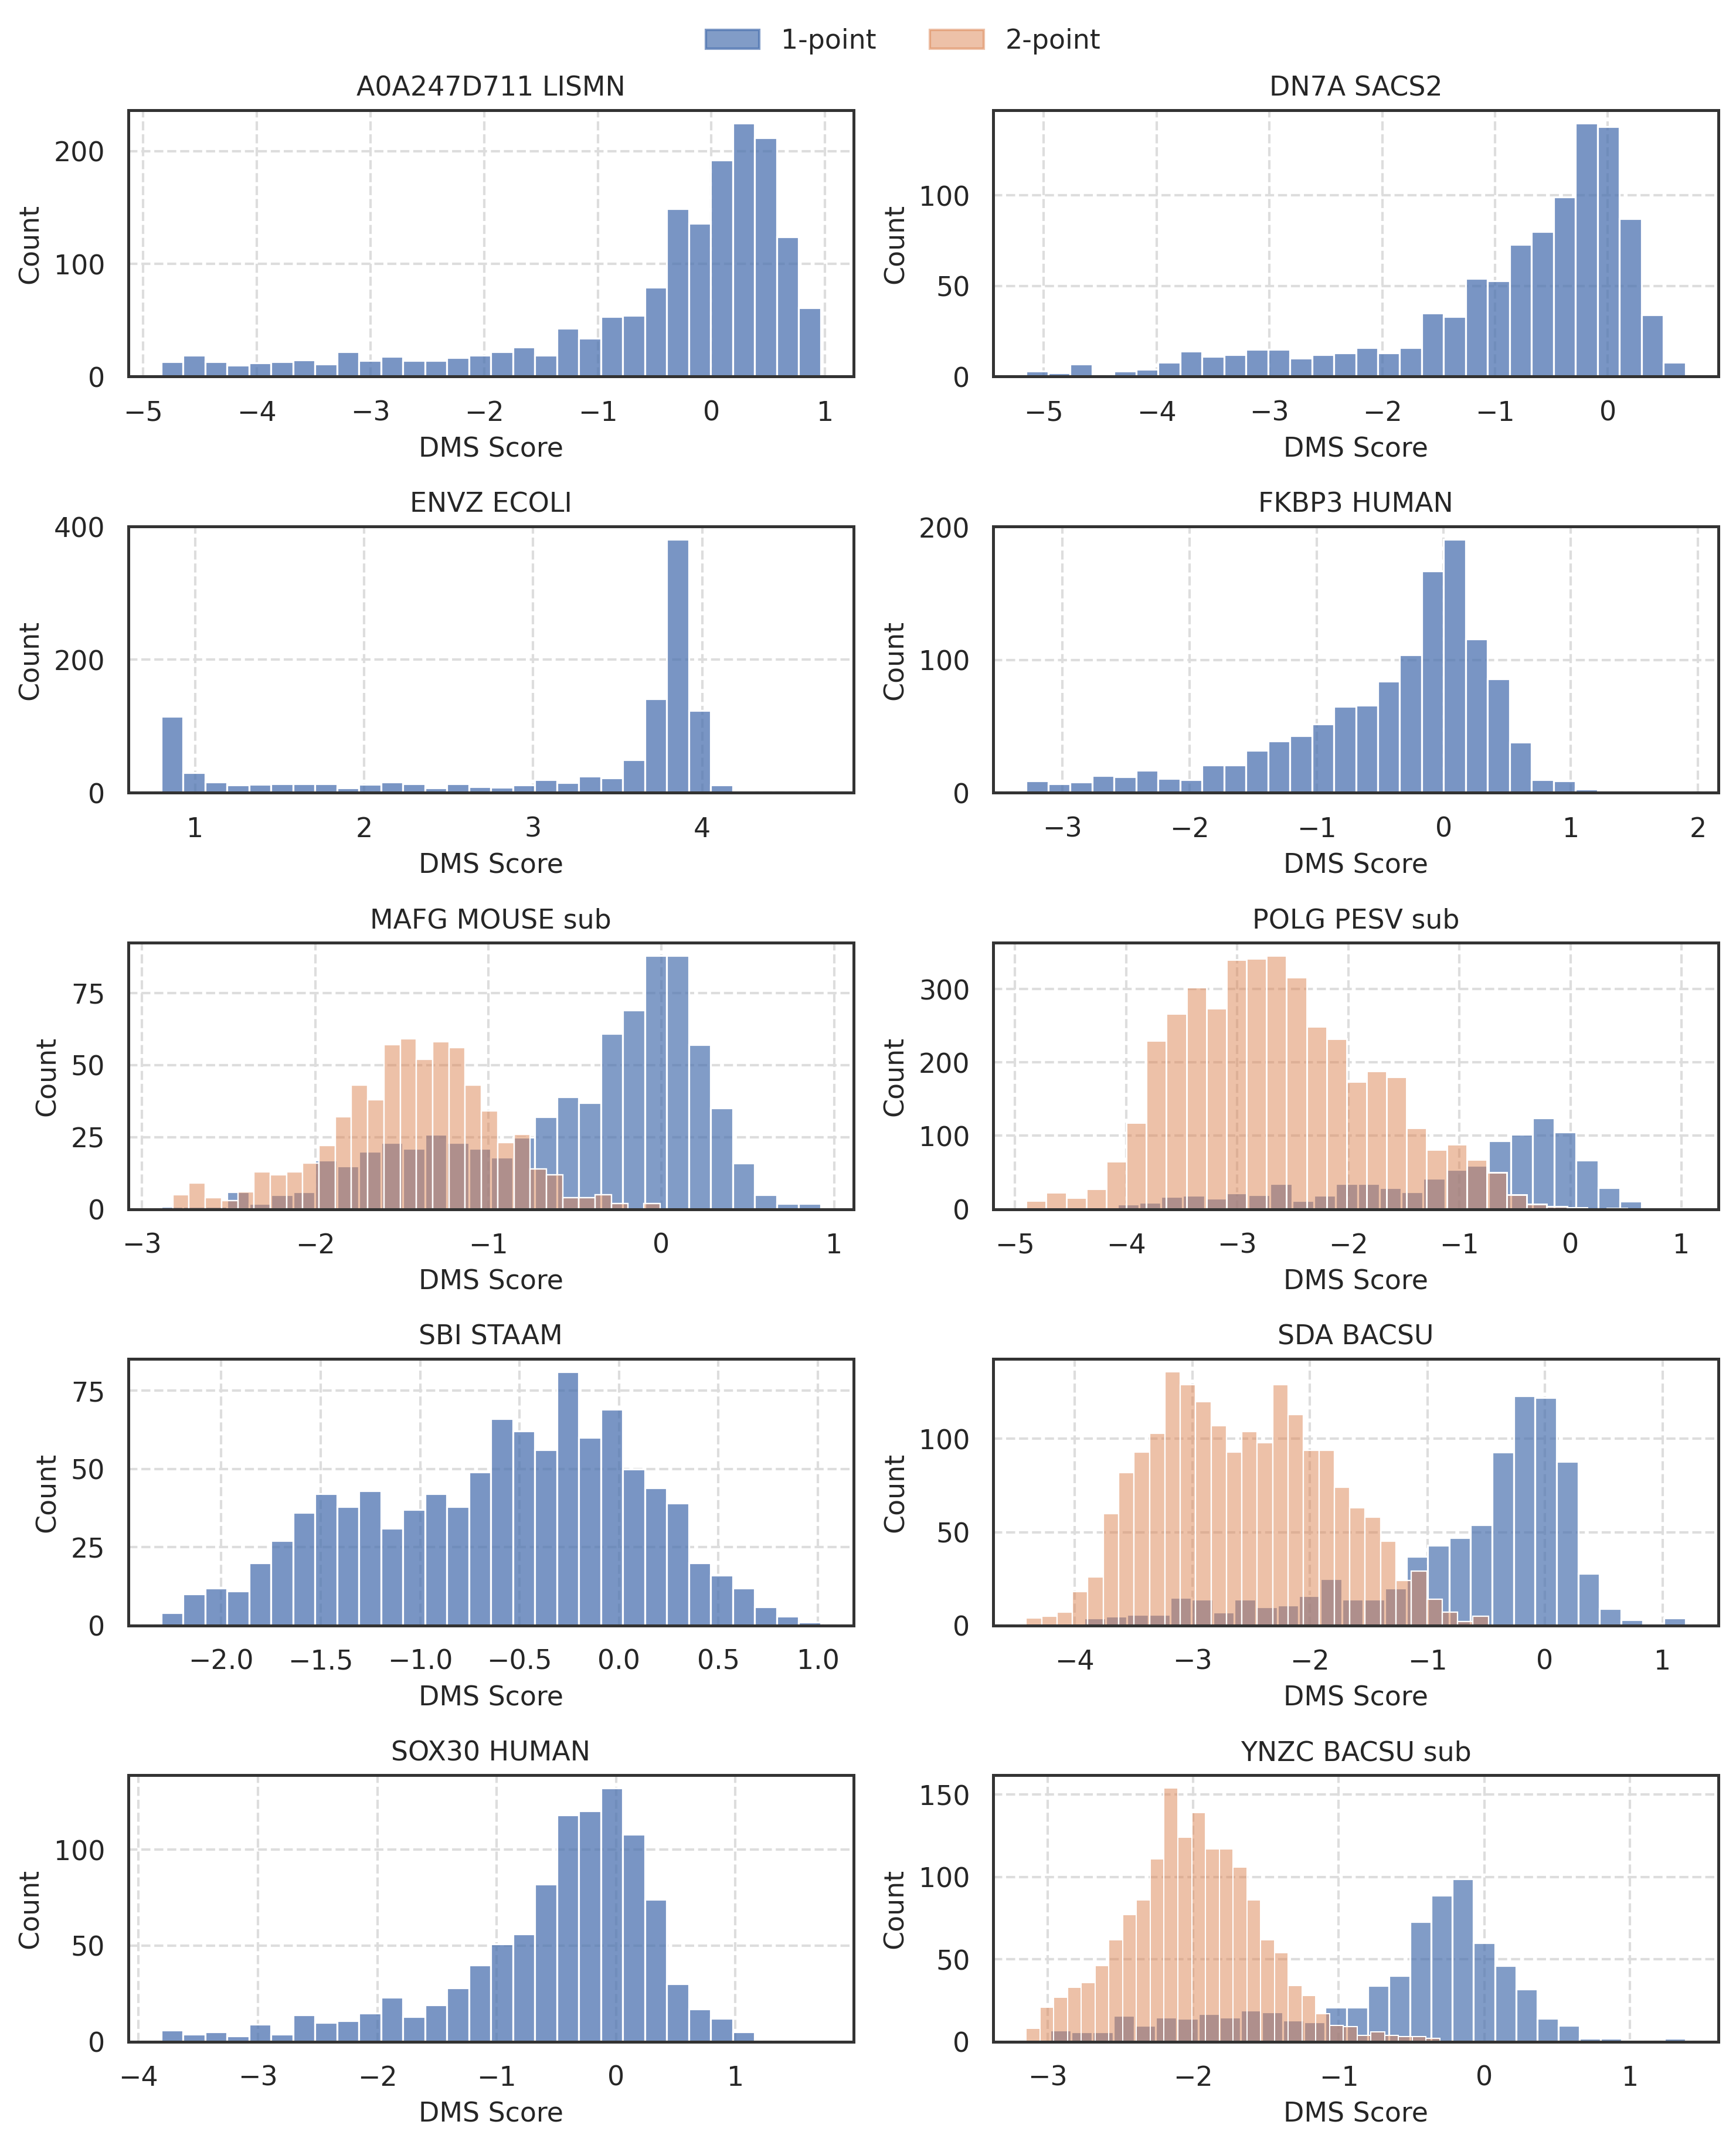

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.patches as mpatches

# ------------------------
# Style (your settings)
# ------------------------
sns.set_theme(
    context="notebook",
    style="whitegrid",
    rc={
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "#333333",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "--",
        "legend.frameon": False,
    }
)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 11,
})

# ------------------------
# Saving: every figure in this notebook is written next to it as PNG and PDF
# ------------------------
def save_figure(fig, stem):
    """Save `fig` as <stem>.png and <stem>.pdf; the tight box keeps the legends in."""
    fig.savefig(f"{stem}.png", bbox_inches="tight")
    fig.savefig(f"{stem}.pdf", bbox_inches="tight")
    print(f"Saved {stem}.png / .pdf")


# ------------------------
# Paths
# ------------------------
processed_dir = "../../../data/proteingym_dms/processed/substitutions/"
files = sorted([f for f in os.listdir(processed_dir) if f.endswith(".csv")])

name_map = {
    "YNZC_BACSU_Tsuboyama_2023_2JVD.csv": "YNZC_BACSU_sub",
    "MAFG_MOUSE_Tsuboyama_2023_1K1V.csv": "MAFG_MOUSE_sub",
    "SDA_BACSU_Tsuboyama_2023_1PV0.csv": "SDA_BACSU",
    "POLG_PESV_Tsuboyama_2023_2MXD.csv": "POLG_PESV_sub",
    "DN7A_SACS2_Tsuboyama_2023_1JIC.csv": "DN7A_SACS2",
    "SBI_STAAM_Tsuboyama_2023_2JVG.csv": "SBI_STAAM",
    "SOX30_HUMAN_Tsuboyama_2023_7JJK.csv": "SOX30_HUMAN",
    "ENVZ_ECOLI_Ghose_2023.csv": "ENVZ_ECOLI",
    "FKBP3_HUMAN_Tsuboyama_2023_2KFV.csv": "FKBP3_HUMAN",
    "A0A247D711_LISMN_Stadelmann_2021.csv": "A0A247D711_LISMN"
}

# Colors for 1- and 2-point mutations
COLOR_ONE = "#4C72B0"
COLOR_TWO = "#DD8452"

# ------------------------
# Create 5x2 grid
# ------------------------
fig, axes = plt.subplots(5, 2, figsize=(10, 12))
axes = axes.flatten()

# ------------------------
# Loop through datasets
# ------------------------
for i, file_name in enumerate(files):
    ax = axes[i]
    file_path = os.path.join(processed_dir, file_name)

    df = pd.read_csv(file_path)

    # Recompute mutation counts
    mutation_counts = df["mutant"].astype(str).apply(lambda x: len(x.split(":")))

    one_mut = df[mutation_counts == 1]["score"]
    two_mut = df[mutation_counts == 2]["score"]

    # ------------------------
    # Plot logic
    # ------------------------
    if len(one_mut) > 0 and len(two_mut) > 0:
        sns.histplot(one_mut, bins=30, ax=ax, alpha=0.7, color=COLOR_ONE)
        sns.histplot(two_mut, bins=30, ax=ax, alpha=0.5, color=COLOR_TWO)
    elif len(one_mut) > 0:
        sns.histplot(one_mut, bins=30, ax=ax, color=COLOR_ONE)
    elif len(two_mut) > 0:
        sns.histplot(two_mut, bins=30, ax=ax, color=COLOR_TWO)
    else:
        sns.histplot(df["score"], bins=30, ax=ax, color=COLOR_ONE)

    # Title cleanup
    ax.set_title(pretty_dataset(name_map.get(file_name, file_name.replace(".csv", ""))))
    ax.set_xlabel("DMS Score")
    ax.set_ylabel("Count")

# ------------------------
# Remove empty subplots (if any)
# ------------------------
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ------------------------
# Single legend at top center
# ------------------------
handles = [
    mpatches.Patch(color=COLOR_ONE, alpha=0.7, label="1-point"),
    mpatches.Patch(color=COLOR_TWO, alpha=0.5, label="2-point")
]

fig.legend(
    handles=handles,
    loc='upper center',
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.52, 1.02)
)

plt.tight_layout()
save_figure(fig, "data_substitutions_scores")
plt.show()

### Indels

Saved data_indels_scores.png / .pdf


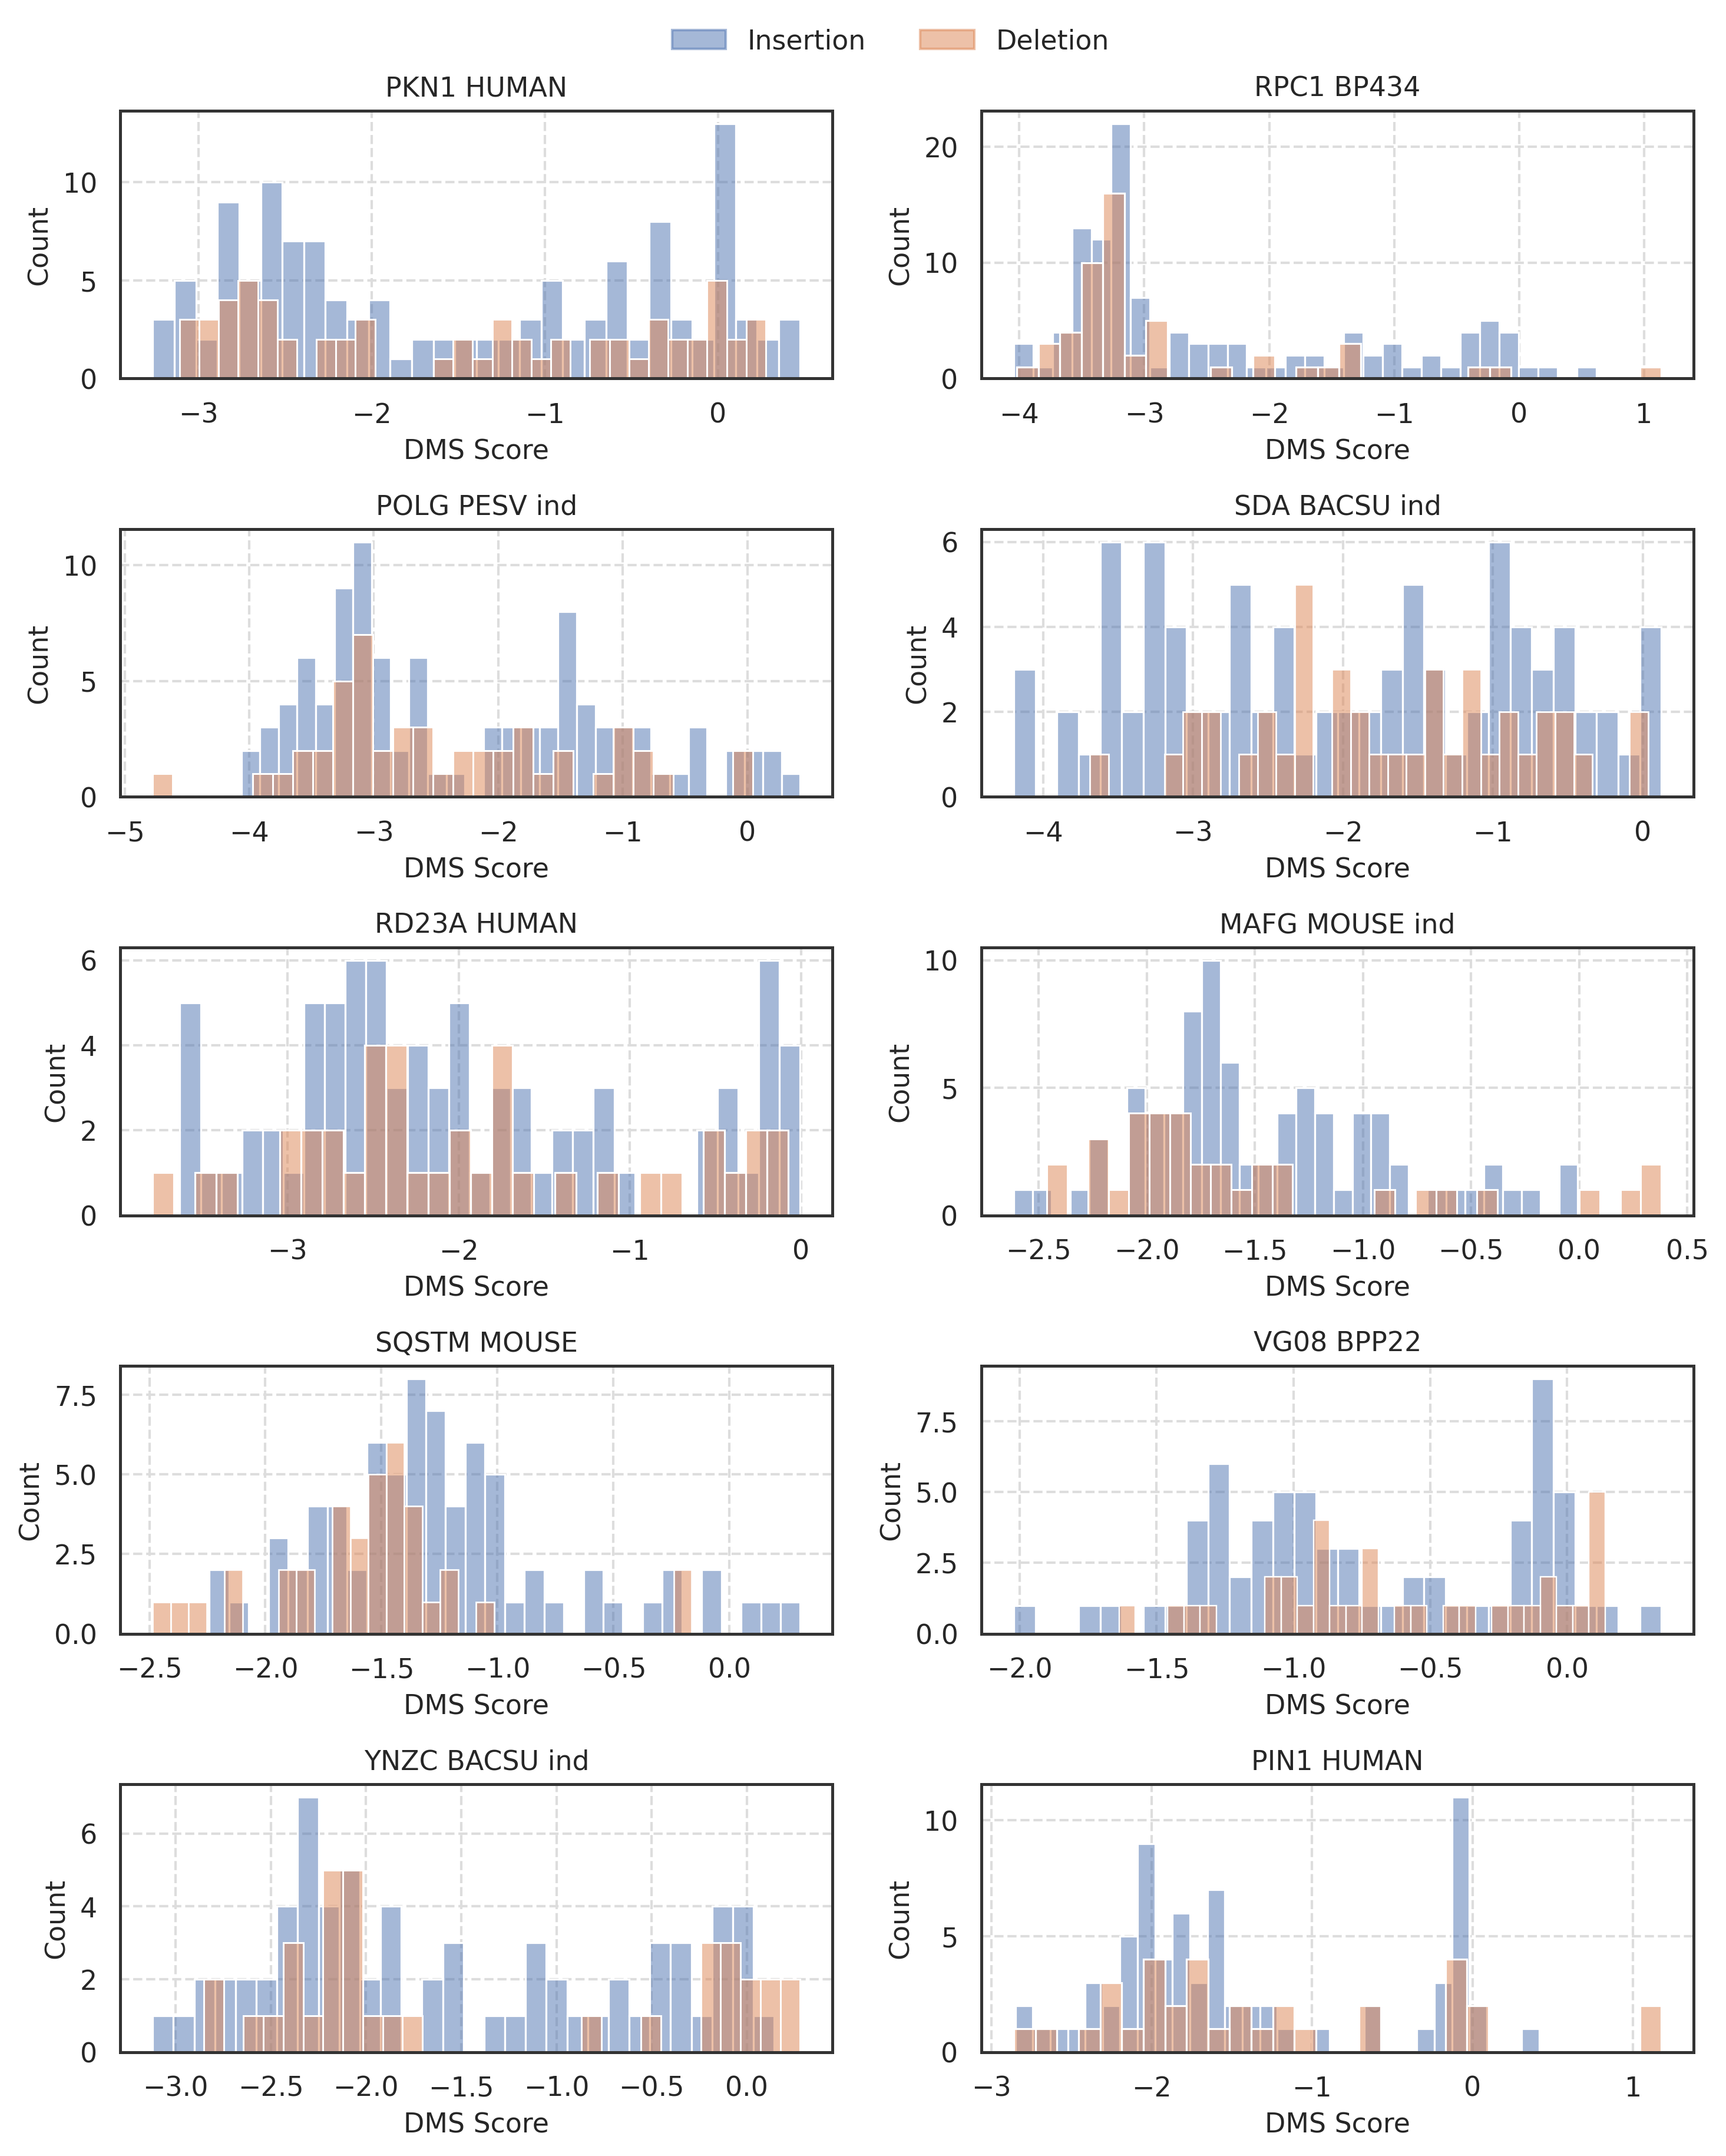

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.patches as mpatches

# ------------------------
# Style (unchanged)
# ------------------------
sns.set_theme(
    context="notebook",
    style="whitegrid",
    rc={
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "#333333",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "--",
        "legend.frameon": False,
    }
)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 11,
})

# ------------------------
# Path (processed data)
# ------------------------
processed_dir = "../../../data/proteingym_dms/processed/indels/"

files = [
    "PKN1_HUMAN_Tsuboyama_2023_1URF_indels.csv",
    "RPC1_BP434_Tsuboyama_2023_1R69_indels.csv",
    "POLG_PESV_Tsuboyama_2023_2MXD_indels.csv",
    "SDA_BACSU_Tsuboyama_2023_1PV0_indels.csv",
    "RD23A_HUMAN_Tsuboyama_2023_1IFY_indels.csv",
    "MAFG_MOUSE_Tsuboyama_2023_1K1V_indels.csv",
    "SQSTM_MOUSE_Tsuboyama_2023_2RRU_indels.csv",
    "VG08_BPP22_Tsuboyama_2023_2GP8_indels.csv",
    "YNZC_BACSU_Tsuboyama_2023_2JVD_indels.csv",
    "PIN1_HUMAN_Tsuboyama_2023_1I6C_indels.csv",
]

# ------------------------
# Custom names
# ------------------------
name_map = {
    "PIN1_HUMAN_Tsuboyama_2023_1I6C_indels.csv": "PIN1_HUMAN",
    "YNZC_BACSU_Tsuboyama_2023_2JVD_indels.csv": "YNZC_BACSU_ind",
    "VG08_BPP22_Tsuboyama_2023_2GP8_indels.csv": "VG08_BPP22",
    "SQSTM_MOUSE_Tsuboyama_2023_2RRU_indels.csv": "SQSTM_MOUSE",
    "MAFG_MOUSE_Tsuboyama_2023_1K1V_indels.csv": "MAFG_MOUSE_ind",
    "RD23A_HUMAN_Tsuboyama_2023_1IFY_indels.csv": "RD23A_HUMAN",
    "SDA_BACSU_Tsuboyama_2023_1PV0_indels.csv": "SDA_BACSU_ind",
    "POLG_PESV_Tsuboyama_2023_2MXD_indels.csv": "POLG_PESV_ind",
    "RPC1_BP434_Tsuboyama_2023_1R69_indels.csv": "RPC1_BP434",
    "PKN1_HUMAN_Tsuboyama_2023_1URF_indels.csv": "PKN1_HUMAN",
}

# ------------------------
# Colors (match substitutions)
# ------------------------
COLOR_INSERT = "#4C72B0"   # Blue
COLOR_DELETE = "#DD8452"   # Orange

# ------------------------
# Create 5x2 grid
# ------------------------
fig, axes = plt.subplots(5, 2, figsize=(10, 12))
axes = axes.flatten()

# ------------------------
# Loop through files
# ------------------------
for i, file_name in enumerate(files):
    ax = axes[i]
    file_path = os.path.join(processed_dir, file_name)
    df = pd.read_csv(file_path)

    # ------------------------
    # Infer WT length
    # ------------------------
    seq_lengths = df["sequence"].str.len()
    wt_len = (seq_lengths.min() + seq_lengths.max()) / 2
    length_diff = df["sequence"].str.len() - wt_len

    insertions = df[length_diff > 0]["score"]
    deletions  = df[length_diff < 0]["score"]

    # ------------------------
    # Plot histograms
    # ------------------------
    if len(insertions) > 0:
        sns.histplot(
            insertions,
            bins=30,
            ax=ax,
            alpha=0.5,
            color=COLOR_INSERT
        )

    if len(deletions) > 0:
        sns.histplot(
            deletions,
            bins=30,
            ax=ax,
            alpha=0.5,
            color=COLOR_DELETE
        )

    # ------------------------
    # Labels
    # ------------------------
    ax.set_title(pretty_dataset(name_map[file_name]))
    ax.set_xlabel("DMS Score")
    ax.set_ylabel("Count")

# ------------------------
# Remove empty axes
# ------------------------
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ------------------------
# Single legend at top center
# ------------------------
handles = [
    mpatches.Patch(color=COLOR_INSERT, alpha=0.5, label="Insertion"),
    mpatches.Patch(color=COLOR_DELETE, alpha=0.5, label="Deletion")
]

fig.legend(
    handles=handles,
    loc='upper center',
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.52, 1.02)
)

plt.tight_layout()
save_figure(fig, "data_indels_scores")
plt.show()

### Peptide datasets

The E.coli / S.aureus / P.aeruginosa AMP datasets and HemoPI2 haemolysis. Each is
read from the fused, processed file written by *process_data.ipynb*.


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.patches as mpatches

# ------------------------
# Style (same as the cells above)
# ------------------------
sns.set_theme(
    context="notebook",
    style="whitegrid",
    rc={
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "#333333",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "--",
        "legend.frameon": False,
    }
)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 11,
})

# ------------------------
# Paths and colors shared by the peptide-dataset cells below
# ------------------------
base_dir = "../../../data/"

peptide_paths = {
    "E.coli AMPs":         os.path.join(base_dir, "ecoli_amps/processed/EC_all_40.csv"),
    "S.aureus AMPs":       os.path.join(base_dir, "saureus_amps/processed/SA_all_40.csv"),
    "P.aeruginosa AMPs":   os.path.join(base_dir, "paeruginosa_amps/processed/PA_all_40.csv"),
    "HemoPI2":             os.path.join(base_dir, "hemopi2/processed/hemopi2_all.csv"),
}

score_labels = {
    "E.coli AMPs":       "Score (pMIC)",
    "S.aureus AMPs":     "Score (pMIC)",
    "P.aeruginosa AMPs": "Score (pMIC)",
    "HemoPI2":           r"Score (pHC$_{50}$)",
}

MAIN_COLOR = "#4C72B0"
CLASS_COLORS = ["#4C72B0", "#DD8452"]


def load_peptide_datasets(paths):
    """Load whichever processed peptide datasets exist, reporting any that are missing."""
    loaded = {}
    for name, path in paths.items():
        if os.path.exists(path):
            loaded[name] = pd.read_csv(path)
        else:
            print(f"Missing (run process_data.ipynb first): {name} -> {path}")
    return loaded


peptide_data = load_peptide_datasets(peptide_paths)
print(f"\nLoaded {len(peptide_data)} peptide datasets: {list(peptide_data)}")



Loaded 4 peptide datasets: ['E.coli AMPs', 'S.aureus AMPs', 'P.aeruginosa AMPs', 'HemoPI2']


#### Score and length distributions — all peptide datasets

The three AMP potency datasets (pMIC) and HemoPI2 haemolysis (pHC$_{50}$), one subplot each.


Saved data_peptides_scores.png / .pdf


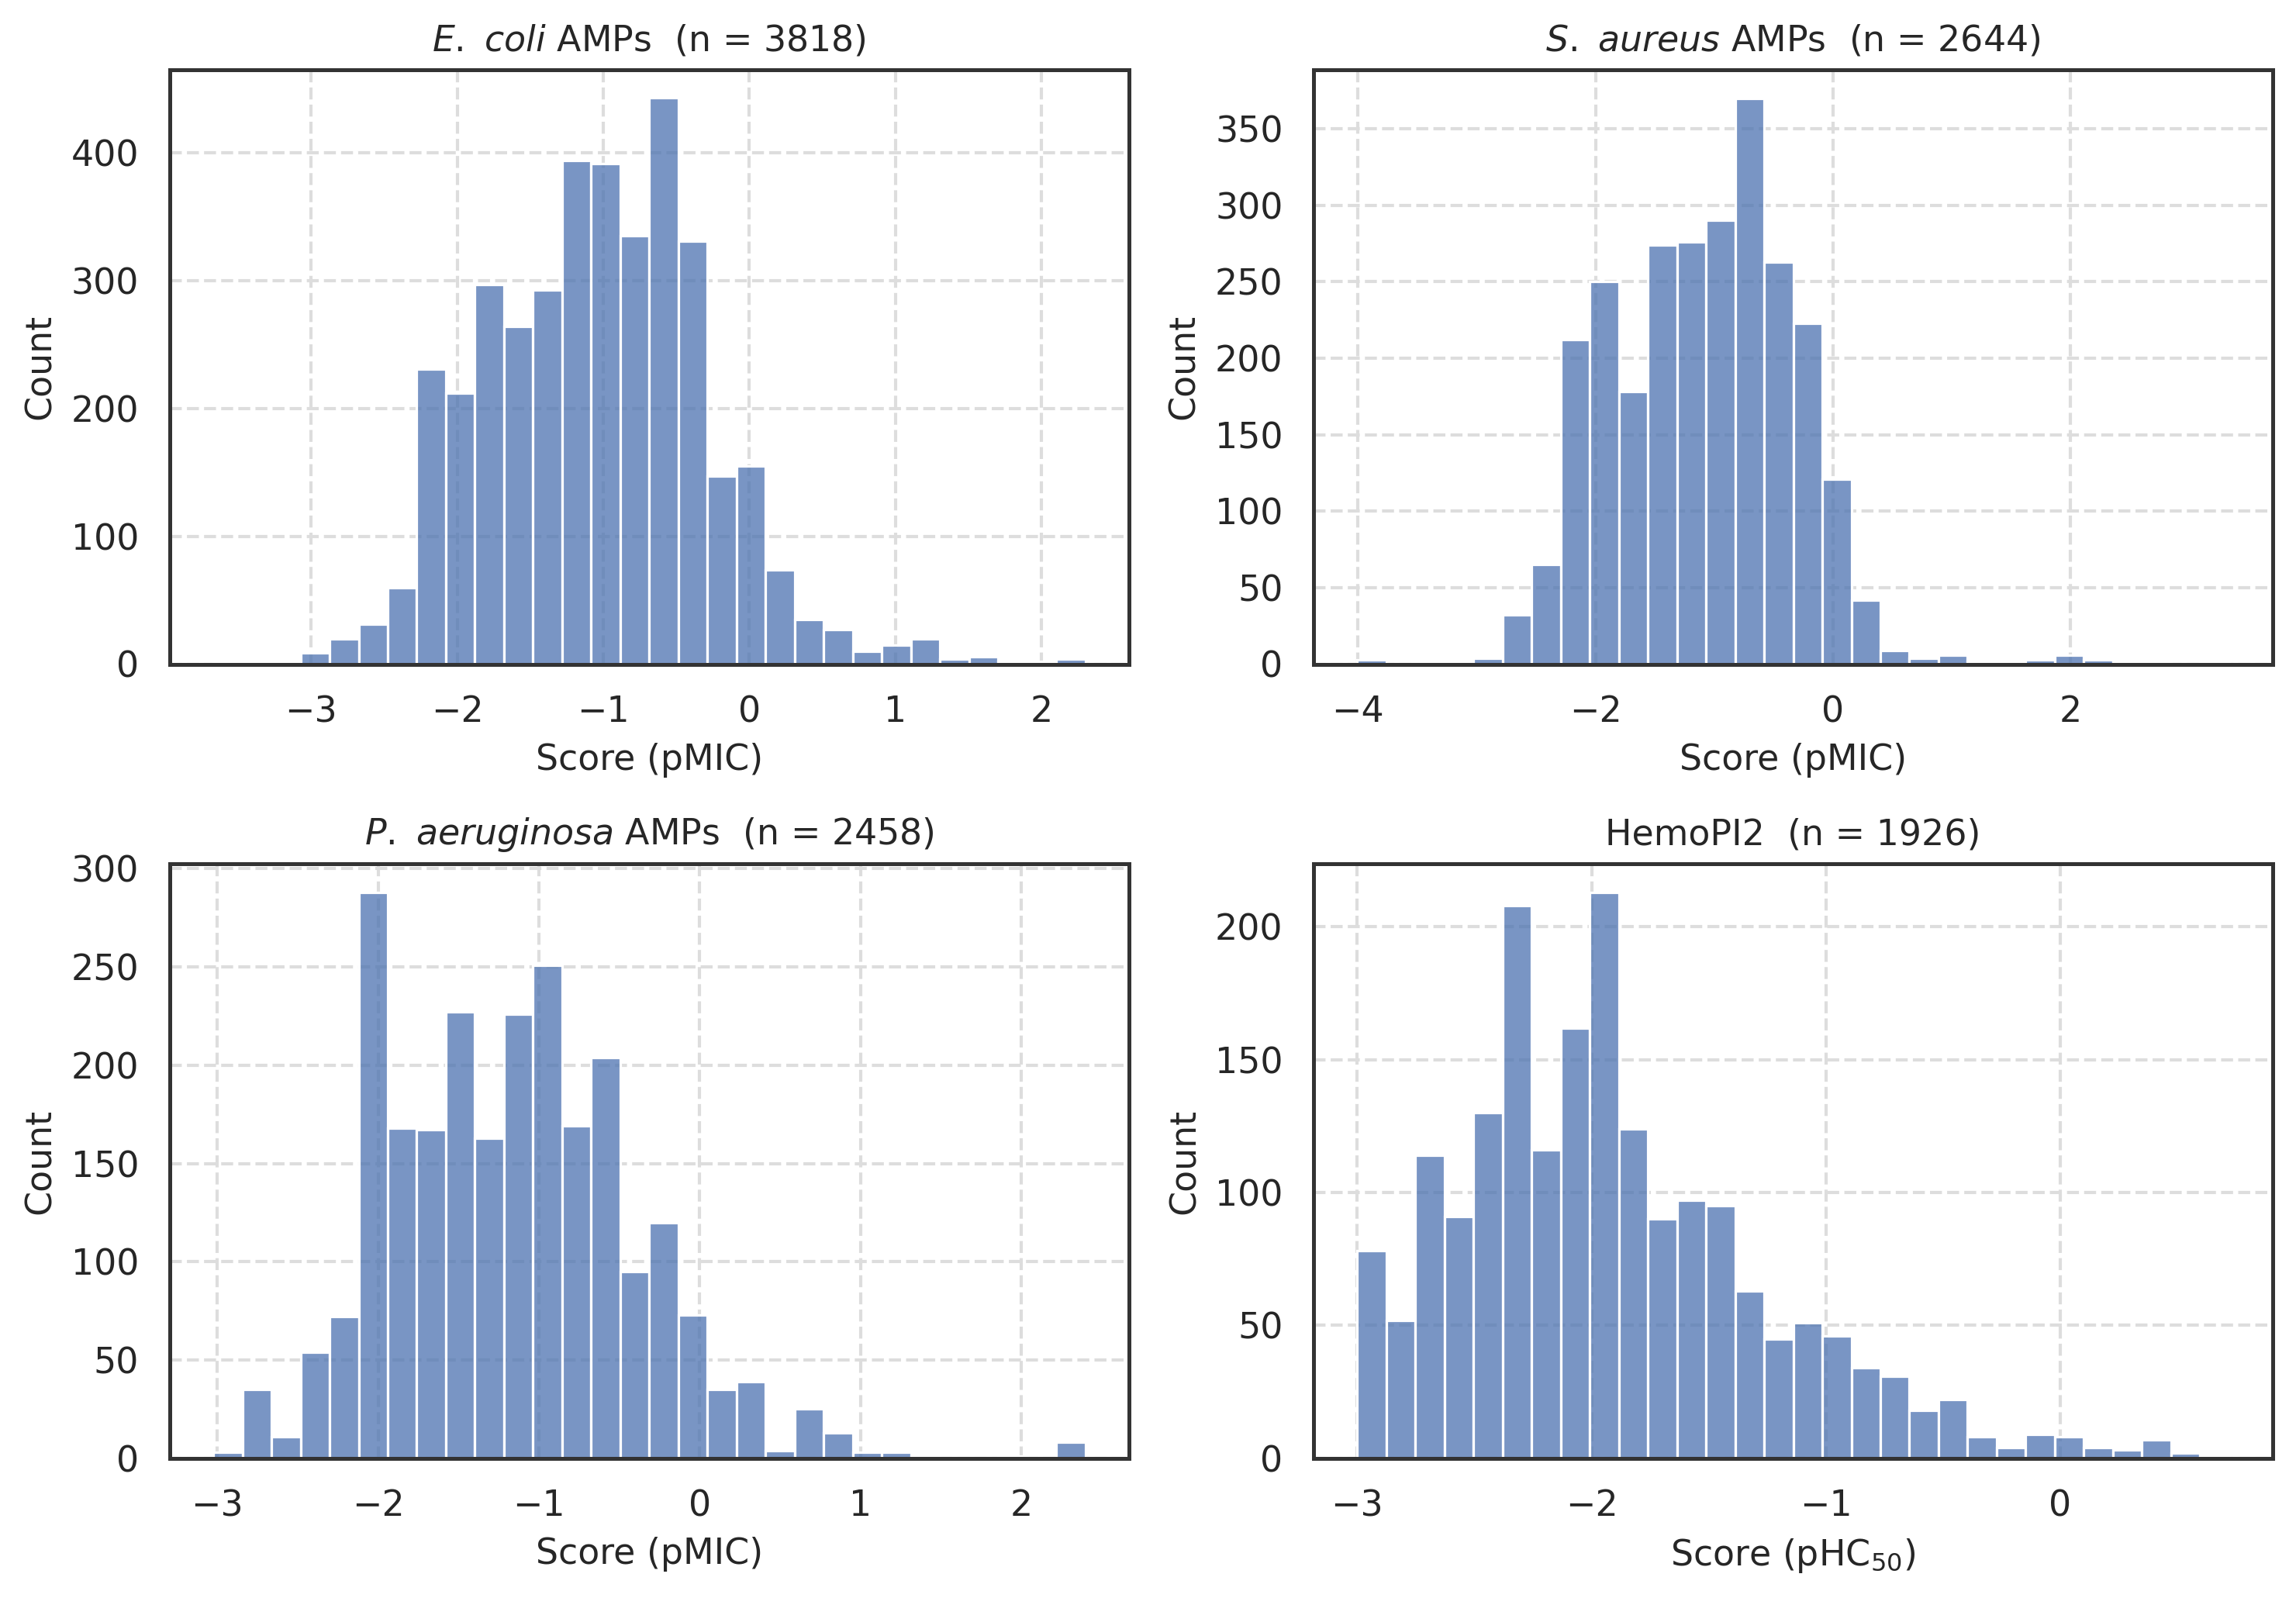

Saved data_peptides_lengths.png / .pdf


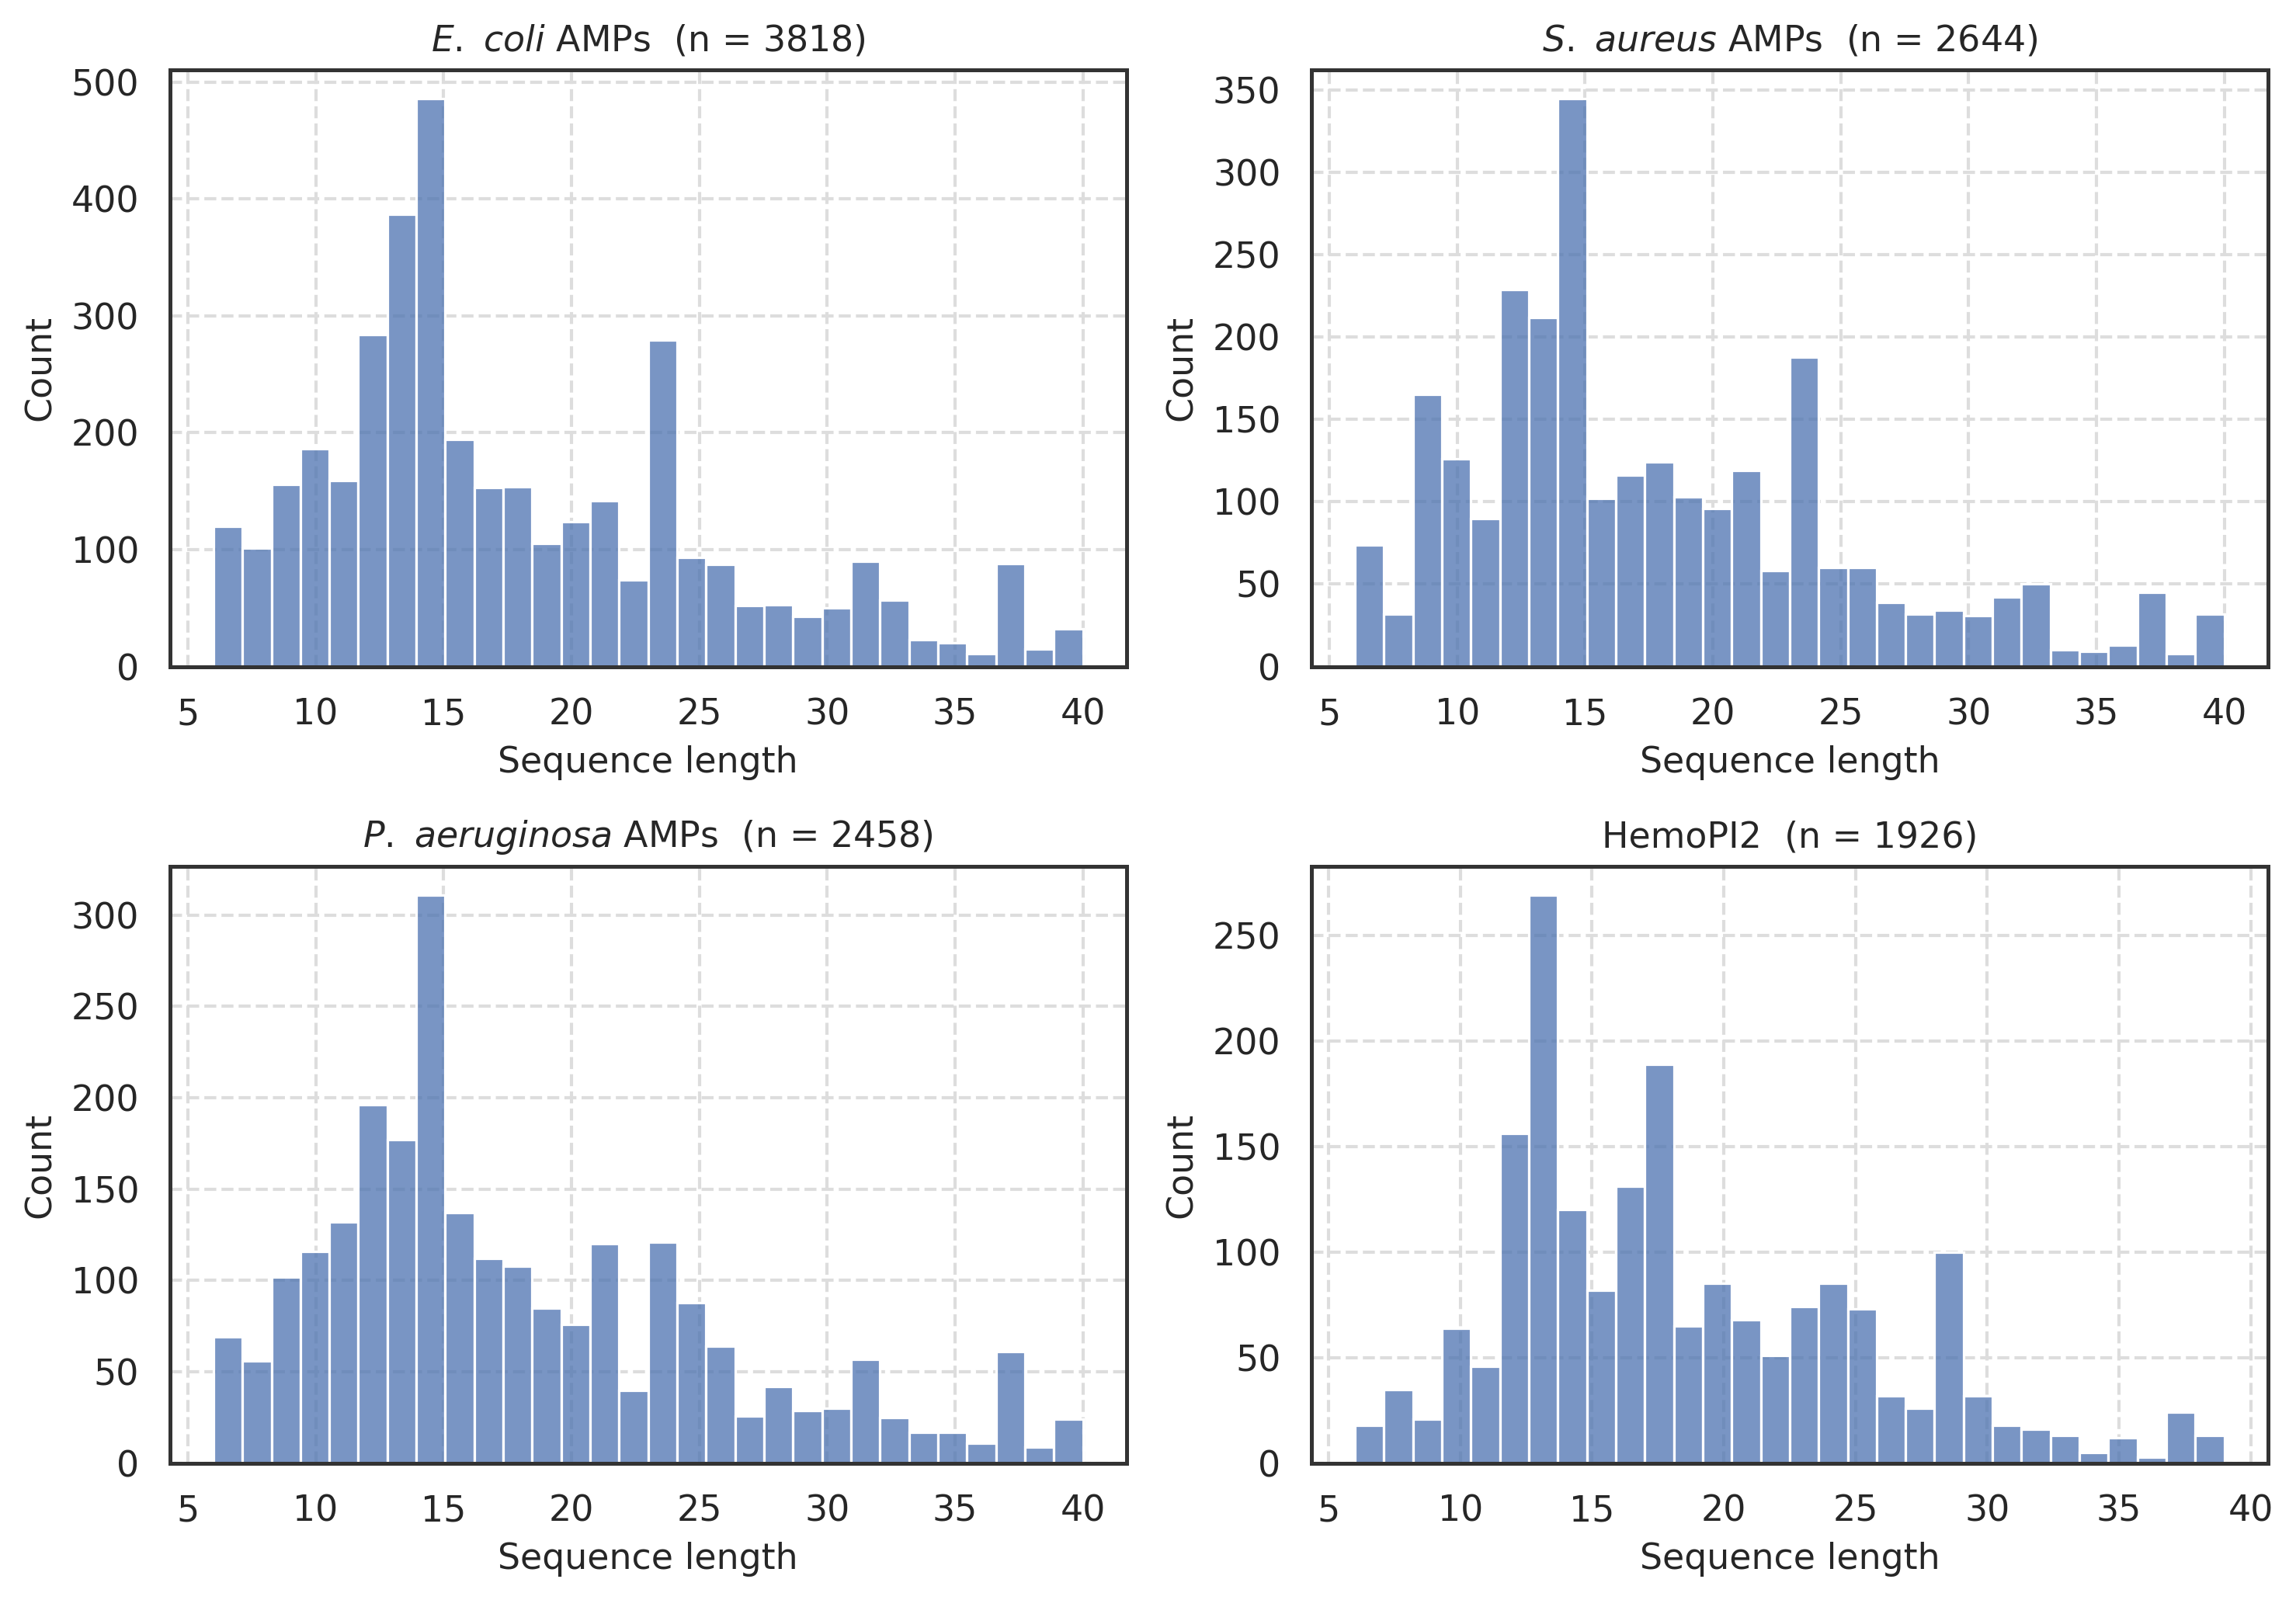

In [5]:
# ------------------------
# Score distributions for all four peptide datasets, one subplot each
# (the three AMP potency sets and HemoPI2 haemolysis)
# ------------------------
amp_names = [n for n in ["E.coli AMPs", "S.aureus AMPs", "P.aeruginosa AMPs", "HemoPI2"]
             if n in peptide_data]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, name in enumerate(amp_names):
    ax = axes[i]
    df = peptide_data[name]

    sns.histplot(df["score"], bins=30, ax=ax, color=MAIN_COLOR)
    ax.set_title(f"{pretty_dataset(name)}  (n = {len(df)})")
    ax.set_xlabel(score_labels[name])
    ax.set_ylabel("Count")

for j in range(len(amp_names), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
save_figure(fig, "data_peptides_scores")
plt.show()

# ------------------------
# Sequence length distributions for the same datasets
# ------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, name in enumerate(amp_names):
    ax = axes[i]
    df = peptide_data[name]

    sns.histplot(df["sequence_length"], bins=30, ax=ax, color=MAIN_COLOR)
    ax.set_title(f"{pretty_dataset(name)}  (n = {len(df)})")
    ax.set_xlabel("Sequence length")
    ax.set_ylabel("Count")

for j in range(len(amp_names), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
save_figure(fig, "data_peptides_lengths")
plt.show()


### Range of each dataset

In [6]:
import os
import pandas as pd

# ------------------------
# Define all processed dataset paths
# ------------------------

base_dirs = {
    "substitutions":     "../../../data/proteingym_dms/processed/substitutions/",
    "indels":            "../../../data/proteingym_dms/processed/indels/",
    "E.coli AMPs":       "../../../data/ecoli_amps/processed/",
    "S.aureus AMPs":     "../../../data/saureus_amps/processed/",
    "P.aeruginosa AMPs": "../../../data/paeruginosa_amps/processed/",
    "HemoPI2":           "../../../data/hemopi2/processed/",
}

# List of files for each category
sub_files = [
    "YNZC_BACSU_Tsuboyama_2023_2JVD.csv",
    "MAFG_MOUSE_Tsuboyama_2023_1K1V.csv",
    "SDA_BACSU_Tsuboyama_2023_1PV0.csv",
    "POLG_PESV_Tsuboyama_2023_2MXD.csv",
    "DN7A_SACS2_Tsuboyama_2023_1JIC.csv",
    "SBI_STAAM_Tsuboyama_2023_2JVG.csv",
    "SOX30_HUMAN_Tsuboyama_2023_7JJK.csv",
    "ENVZ_ECOLI_Ghose_2023.csv",
    "FKBP3_HUMAN_Tsuboyama_2023_2KFV.csv",
    "A0A247D711_LISMN_Stadelmann_2021.csv"
]

indel_files = [
    "PKN1_HUMAN_Tsuboyama_2023_1URF_indels.csv",
    "RPC1_BP434_Tsuboyama_2023_1R69_indels.csv",
    "POLG_PESV_Tsuboyama_2023_2MXD_indels.csv",
    "SDA_BACSU_Tsuboyama_2023_1PV0_indels.csv",
    "RD23A_HUMAN_Tsuboyama_2023_1IFY_indels.csv",
    "MAFG_MOUSE_Tsuboyama_2023_1K1V_indels.csv",
    "SQSTM_MOUSE_Tsuboyama_2023_2RRU_indels.csv",
    "VG08_BPP22_Tsuboyama_2023_2GP8_indels.csv",
    "YNZC_BACSU_Tsuboyama_2023_2JVD_indels.csv",
    "PIN1_HUMAN_Tsuboyama_2023_1I6C_indels.csv"
]

# AMP and haemolysis datasets — the fused files written by process_data.ipynb
other_files = {
    "E.coli AMPs":       "EC_all_40.csv",
    "S.aureus AMPs":     "SA_all_40.csv",
    "P.aeruginosa AMPs": "PA_all_40.csv",
    "HemoPI2":           "hemopi2_all.csv",
}

# ------------------------
# Storage for results
# ------------------------
summary_rows = []

# ------------------------
# Helper function to compute min/max
# ------------------------
def get_dataset_summary(file_path, score_col="score"):
    if not os.path.exists(file_path):
        return None
    df = pd.read_csv(file_path)
    if score_col not in df.columns:
        # fallback: use first numeric column
        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) == 0:
            return None
        score_col = num_cols[0]
    return {
        "n": len(df),
        "min": df[score_col].min(),
        "max": df[score_col].max(),
        "mean": df[score_col].mean(),
    }

# ------------------------
# Process substitutions
# ------------------------
for f in sub_files:
    path = os.path.join(base_dirs["substitutions"], f)
    stats = get_dataset_summary(path)
    if stats is None:
        print(f"Missing: {path}")
        continue
    summary_rows.append({"dataset": f.replace(".csv", ""), "type": "substitution", **stats})

# ------------------------
# Process indels
# ------------------------
for f in indel_files:
    path = os.path.join(base_dirs["indels"], f)
    stats = get_dataset_summary(path)
    if stats is None:
        print(f"Missing: {path}")
        continue
    summary_rows.append({"dataset": f.replace(".csv", ""), "type": "indel", **stats})

# ------------------------
# Process other datasets
# ------------------------
for key, f in other_files.items():
    path = os.path.join(base_dirs[key], f)
    stats = get_dataset_summary(path)
    if stats is None:
        print(f"Missing: {path}")
        continue
    summary_rows.append({"dataset": key, "type": "other", **stats})

# ------------------------
# Combine into DataFrame
# ------------------------
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by=["type", "dataset"]).reset_index(drop=True)
summary_df[["min", "max", "mean"]] = summary_df[["min", "max", "mean"]].round(3)

print(summary_df.to_string(index=False))


                               dataset         type    n    min    max   mean
 MAFG_MOUSE_Tsuboyama_2023_1K1V_indels        indel  115 -2.615  0.380 -1.475
 PIN1_HUMAN_Tsuboyama_2023_1I6C_indels        indel  106 -2.859  1.176 -1.372
 PKN1_HUMAN_Tsuboyama_2023_1URF_indels        indel  187 -3.263  0.476 -1.480
  POLG_PESV_Tsuboyama_2023_2MXD_indels        indel  149 -4.774  0.424 -2.311
RD23A_HUMAN_Tsuboyama_2023_1IFY_indels        indel  120 -3.787 -0.004 -1.940
 RPC1_BP434_Tsuboyama_2023_1R69_indels        indel  164 -4.044  1.139 -2.560
  SDA_BACSU_Tsuboyama_2023_1PV0_indels        indel  127 -4.195  0.123 -1.906
SQSTM_MOUSE_Tsuboyama_2023_2RRU_indels        indel  111 -2.485  0.305 -1.332
 VG08_BPP22_Tsuboyama_2023_2GP8_indels        indel  101 -2.022  0.345 -0.681
 YNZC_BACSU_Tsuboyama_2023_2JVD_indels        indel  104 -3.119  0.280 -1.484
                           E.coli AMPs        other 3818 -3.670  2.301 -1.035
                               HemoPI2        other 1926 -3.000 